# Chapter 1: Essential Math Toolkit

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/arunpshankar/packt-final/blob/main/code/notebooks/part1_foundations/01_math_toolkit.ipynb)

> **Book:** *Reinforcement Learning for Large Language Models* — Arun Shankar & Michael Chertushkin (Packt, 2025)  
> **Chapter 1:** Essential Math Toolkit  
> **Notebook:** `part1_foundations/01_math_toolkit.ipynb`

---

## What this notebook covers

This is the companion notebook for Chapter 1 of the book. Run it on a free Colab T4 GPU. All code uses small, publicly available models (under 500 MB) that fit within the free tier memory limit.

**To open in Colab:** Click the badge above, or replace `github.com` with `githubtocolab.com` in the URL.


## Environment Setup

We detect whether we are running inside Google Colab so we only install packages in that environment. Locally, assume the packages are already present in your virtual environment.

In [1]:
import sys

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    %pip install -q numpy matplotlib torch

print(f'Running in Colab: {IN_COLAB}')

Running in Colab: True


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

# Reproducibility
np.random.seed(42)
torch.manual_seed(42)

plt.rcParams.update({'figure.dpi': 110, 'font.size': 11})
print('All imports successful.')

All imports successful.


---
## 1. Probability Distributions: Softmax and Log-Softmax

In an LLM, the final linear layer produces a vector of **logits** — one real-valued score per vocabulary token. The model converts these logits into a probability distribution using the **softmax** function:

$$\text{softmax}(z)_i = \frac{e^{z_i}}{\sum_j e^{z_j}}$$

The **temperature** parameter $T$ controls how peaked or flat the distribution is:

$$\text{softmax}(z / T)_i = \frac{e^{z_i / T}}{\sum_j e^{z_j / T}}$$

- $T \to 0$: distribution collapses to a one-hot (greedy decoding)
- $T = 1$: standard softmax
- $T > 1$: distribution becomes more uniform (more diverse outputs)

As covered in Chapter 3 of the book, the temperature parameter reappears inside the PPO clipping objective when we compare the new policy to the reference policy.

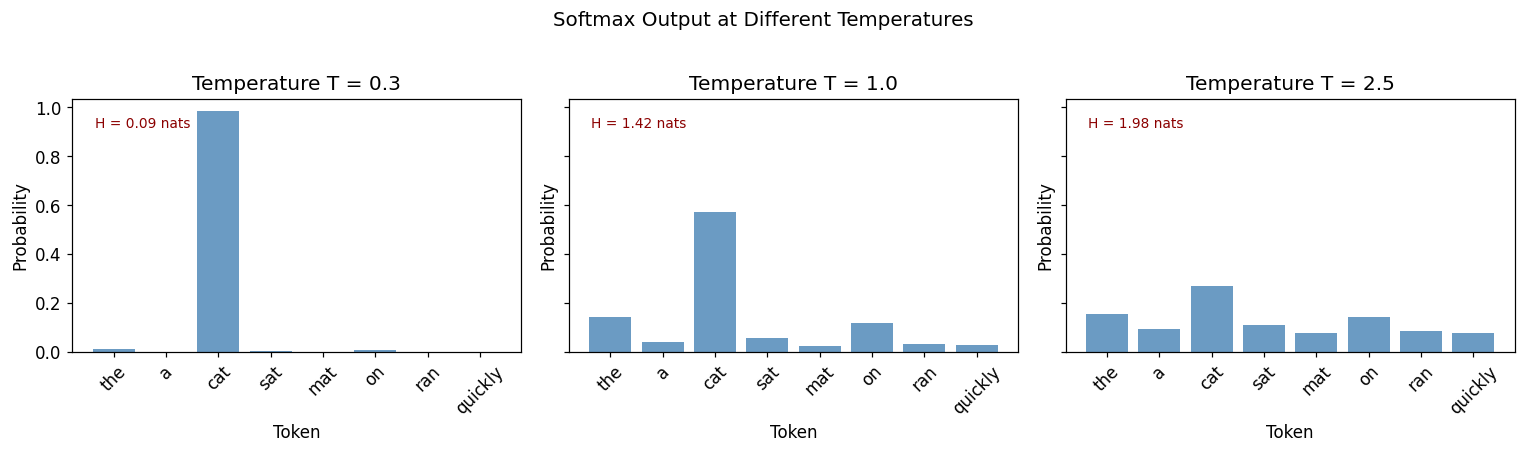

Probabilities at T=1.0:
  the       : 0.1404
  a         : 0.0383
  cat       : 0.5692
  sat       : 0.0571
  mat       : 0.0232
  on        : 0.1149
  ran       : 0.0313
  quickly   : 0.0256


In [3]:
def softmax(logits: np.ndarray, temperature: float = 1.0) -> np.ndarray:
    """Numerically stable softmax with temperature scaling."""
    z = logits / temperature
    z = z - z.max()          # subtract max for numerical stability
    exp_z = np.exp(z)
    return exp_z / exp_z.sum()


# Simulate logits for a small 8-token vocabulary
vocab = ['the', 'a', 'cat', 'sat', 'mat', 'on', 'ran', 'quickly']
logits = np.array([2.1, 0.8, 3.5, 1.2, 0.3, 1.9, 0.6, 0.4])

temperatures = [0.3, 1.0, 2.5]
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)

for ax, T in zip(axes, temperatures):
    probs = softmax(logits, T)
    ax.bar(vocab, probs, color='steelblue', alpha=0.8)
    ax.set_title(f'Temperature T = {T}')
    ax.set_xlabel('Token')
    ax.set_ylabel('Probability')
    ax.tick_params(axis='x', rotation=45)
    entropy = -np.sum(probs * np.log(probs + 1e-12))
    ax.text(0.05, 0.93, f'H = {entropy:.2f} nats',
            transform=ax.transAxes, fontsize=9,
            verticalalignment='top', color='darkred')

plt.suptitle('Softmax Output at Different Temperatures', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print('Probabilities at T=1.0:')
for tok, p in zip(vocab, softmax(logits, 1.0)):
    print(f'  {tok:10s}: {p:.4f}')

### Log-Softmax

We almost always work with **log-probabilities** in RL. The log-softmax is:

$$\log \text{softmax}(z)_i = z_i - \log \sum_j e^{z_j}$$

Taking the log before summing avoids the underflow that occurs when probabilities become extremely small — a common issue with long token sequences. PyTorch's `F.log_softmax` implements this with the log-sum-exp trick automatically.

In [4]:
logits_t = torch.tensor(logits, dtype=torch.float32)

log_probs = F.log_softmax(logits_t, dim=0)
probs_from_log = log_probs.exp()

print(f'{'Token':<12} {'log_prob':>10} {'prob':>10}')
print('-' * 36)
for tok, lp, p in zip(vocab, log_probs.tolist(), probs_from_log.tolist()):
    print(f'{tok:<12} {lp:>10.4f} {p:>10.4f}')

print(f'\nSum of probs:     {probs_from_log.sum().item():.6f}  (must equal 1.0)')
print(f'Sum of log-probs: {log_probs.sum().item():.4f}  (log-space does not sum to 1)')

Token          log_prob       prob
------------------------------------
the             -1.9635     0.1404
a               -3.2635     0.0383
cat             -0.5635     0.5692
sat             -2.8635     0.0571
mat             -3.7635     0.0232
on              -2.1635     0.1149
ran             -3.4635     0.0313
quickly         -3.6635     0.0256

Sum of probs:     1.000000  (must equal 1.0)
Sum of log-probs: -21.7079  (log-space does not sum to 1)


---
## 2. KL Divergence

The **Kullback-Leibler (KL) divergence** measures how much one probability distribution $P$ differs from a reference distribution $Q$:

$$D_{\text{KL}}(P \| Q) = \sum_i P(i) \log \frac{P(i)}{Q(i)}$$

Key properties:
- $D_{\text{KL}}(P \| Q) \geq 0$, with equality only when $P = Q$
- **Not symmetric**: $D_{\text{KL}}(P \| Q) \neq D_{\text{KL}}(Q \| P)$ in general

In RL for LLMs (Chapter 6 onward), we add a KL penalty to prevent the policy from drifting too far from the supervised pre-trained reference model:

$$\mathcal{L} = \mathbb{E}[r(x, y)] - \beta \cdot D_{\text{KL}}(\pi_\theta \| \pi_{\text{ref}})$$

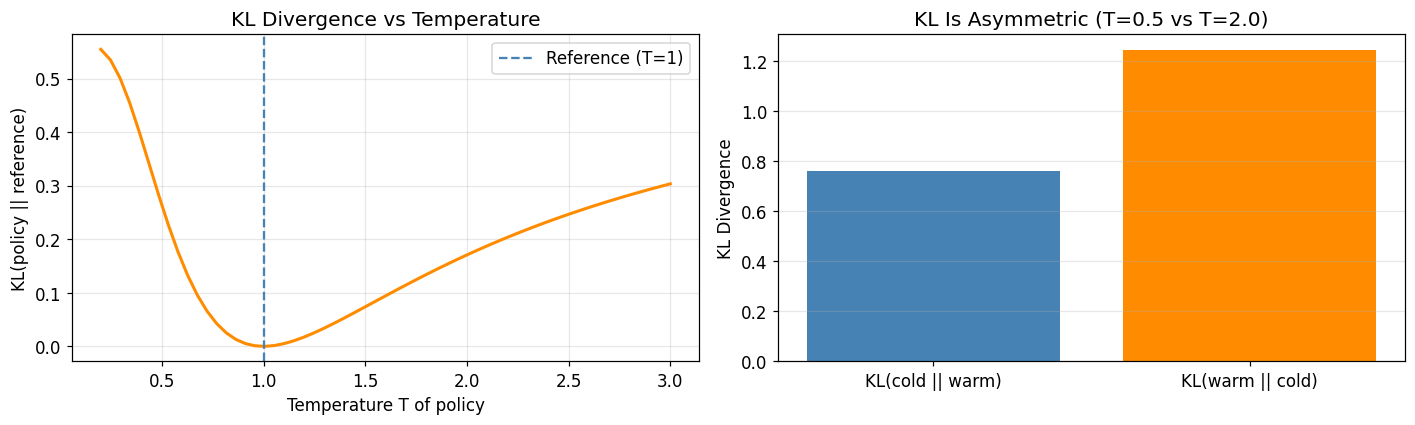

KL(cold || warm) = 0.7627
KL(warm || cold) = 1.2455
KL divergence is NOT symmetric.


In [5]:
def kl_divergence(p: np.ndarray, q: np.ndarray) -> float:
    """KL(P || Q). Small epsilon guards against log(0)."""
    eps = 1e-12
    return float(np.sum(p * np.log((p + eps) / (q + eps))))


# Reference distribution Q: the pre-trained (SFT) model at T=1
q_ref = softmax(logits, temperature=1.0)

# Policy P at various temperatures — sweep from cold to hot
temperature_sweep = np.linspace(0.2, 3.0, 60)
kl_values = [kl_divergence(softmax(logits, T), q_ref) for T in temperature_sweep]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(temperature_sweep, kl_values, color='darkorange', linewidth=2)
ax1.axvline(1.0, color='steelblue', linestyle='--', label='Reference (T=1)')
ax1.set_xlabel('Temperature T of policy')
ax1.set_ylabel('KL(policy || reference)')
ax1.set_title('KL Divergence vs Temperature')
ax1.legend()
ax1.grid(alpha=0.3)

# Demonstrate asymmetry
p_cold = softmax(logits, temperature=0.5)
p_warm = softmax(logits, temperature=2.0)
kl_fwd = kl_divergence(p_cold, p_warm)
kl_rev = kl_divergence(p_warm, p_cold)

ax2.bar(['KL(cold || warm)', 'KL(warm || cold)'], [kl_fwd, kl_rev],
        color=['steelblue', 'darkorange'])
ax2.set_title('KL Is Asymmetric (T=0.5 vs T=2.0)')
ax2.set_ylabel('KL Divergence')
ax2.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f'KL(cold || warm) = {kl_fwd:.4f}')
print(f'KL(warm || cold) = {kl_rev:.4f}')
print('KL divergence is NOT symmetric.')

---
## 3. The Policy Gradient Theorem and the Log-Derivative Trick

The **policy gradient theorem** tells us how to adjust a policy $\pi_\theta$ to maximize expected reward. The key identity is the **log-derivative trick**:

$$\nabla_\theta \pi_\theta(a|s) = \pi_\theta(a|s) \cdot \nabla_\theta \log \pi_\theta(a|s)$$

This transforms the gradient of probabilities (hard to compute from samples) into an expectation we can estimate with rollouts:

$$\nabla_\theta J(\theta) = \mathbb{E}_{\tau \sim \pi_\theta}\left[\sum_t \nabla_\theta \log \pi_\theta(a_t|s_t) \cdot G_t\right]$$

where $G_t$ is the discounted return from step $t$. In Chapter 3 we implement REINFORCE, which is a direct application of this formula.

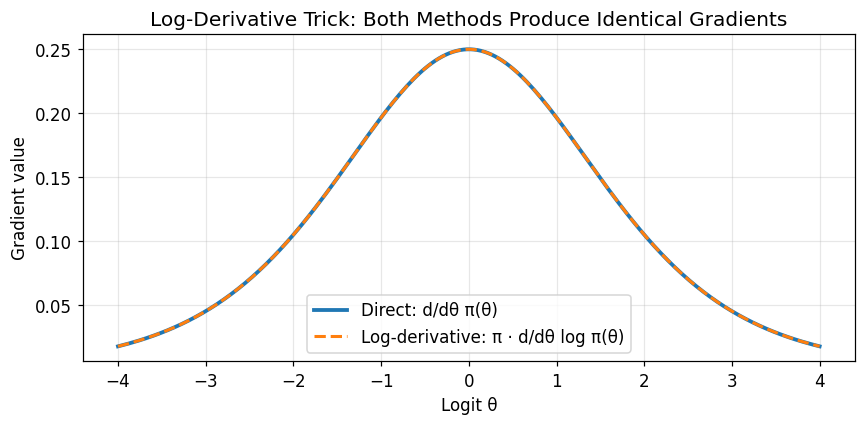

Max absolute difference between methods: 0.00e+00  (machine precision)


In [6]:
# Numerical verification of the log-derivative trick
# pi(a|s) parameterised by a single logit theta for a two-action problem

def pi_sigmoid(theta: float) -> float:
    """Probability of action 0 given logit theta (sigmoid)."""
    return 1.0 / (1.0 + np.exp(-theta))


def grad_pi_direct(theta: float) -> float:
    """Analytic gradient: d/d_theta pi(theta) = pi*(1-pi)."""
    p = pi_sigmoid(theta)
    return p * (1.0 - p)


def grad_pi_log_deriv(theta: float) -> float:
    """Same gradient via log-derivative trick: pi * d/d_theta log(pi)."""
    p = pi_sigmoid(theta)
    # d/d_theta log(sigmoid(theta)) = 1 - sigmoid(theta)
    return p * (1.0 - p)


thetas = np.linspace(-4, 4, 200)
grads_direct = np.array([grad_pi_direct(t) for t in thetas])
grads_logderiv = np.array([grad_pi_log_deriv(t) for t in thetas])

plt.figure(figsize=(8, 4))
plt.plot(thetas, grads_direct, linewidth=2.5,
         label='Direct: d/dθ π(θ)')
plt.plot(thetas, grads_logderiv, linestyle='--', linewidth=2,
         label='Log-derivative: π · d/dθ log π(θ)')
plt.xlabel('Logit θ')
plt.ylabel('Gradient value')
plt.title('Log-Derivative Trick: Both Methods Produce Identical Gradients')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

max_diff = np.max(np.abs(grads_direct - grads_logderiv))
print(f'Max absolute difference between methods: {max_diff:.2e}  (machine precision)')

---
## 4. Expected Return via Monte Carlo Estimation

The **expected return** of a policy is:

$$J(\theta) = \mathbb{E}_{\tau \sim \pi_\theta}[G(\tau)] = \mathbb{E}_{\tau \sim \pi_\theta}\left[\sum_{t=0}^{T} \gamma^t r_t\right]$$

We cannot compute this analytically for complex policies. Instead we use **Monte Carlo estimation**: sample many trajectories and average their returns. More samples give a lower-variance estimate.

As covered in Chapter 3, REINFORCE uses a single trajectory per update — a high-variance but unbiased estimator. PPO and actor-critic methods reduce variance by introducing a value baseline.

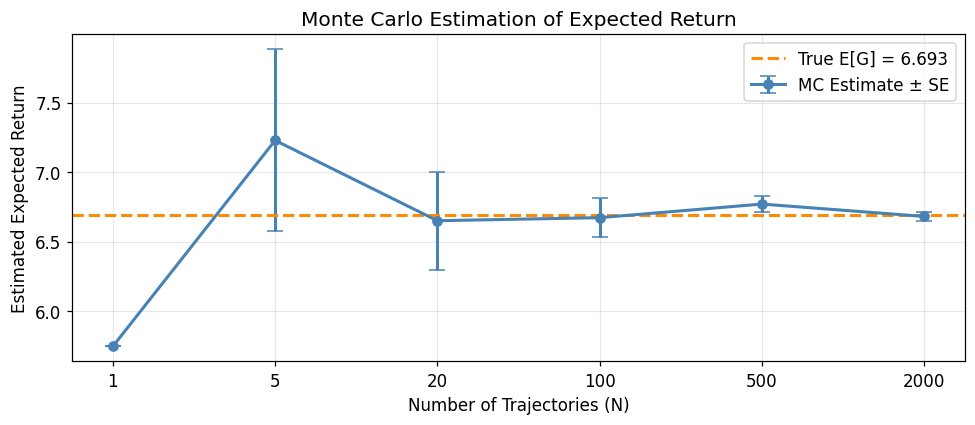

Analytic expected return : 6.6933
MC estimate (N=2000)     : 6.6813


In [7]:
def simulate_trajectory(
    policy_prob: float,
    horizon: int = 10,
    gamma: float = 0.99
) -> float:
    """One trajectory of a Bernoulli policy. Action=1 gives reward=1."""
    total = 0.0
    for t in range(horizon):
        action = np.random.binomial(1, policy_prob)
        total += (gamma ** t) * float(action)
    return total


TRUE_PROB = 0.7
GAMMA = 0.99
HORIZON = 10

analytic_return = TRUE_PROB * sum(GAMMA ** t for t in range(HORIZON))

sample_sizes = [1, 5, 20, 100, 500, 2000]
means, stds = [], []

for n in sample_sizes:
    estimates = [
        simulate_trajectory(TRUE_PROB, HORIZON, GAMMA)
        for _ in range(n)
    ]
    means.append(np.mean(estimates))
    stds.append(np.std(estimates) / np.sqrt(n))

fig, ax = plt.subplots(figsize=(9, 4))
ax.errorbar(
    range(len(sample_sizes)), means, yerr=stds,
    fmt='o-', color='steelblue', capsize=5,
    linewidth=2, label='MC Estimate ± SE'
)
ax.axhline(
    analytic_return, color='darkorange', linestyle='--',
    linewidth=2, label=f'True E[G] = {analytic_return:.3f}'
)
ax.set_xticks(range(len(sample_sizes)))
ax.set_xticklabels([str(n) for n in sample_sizes])
ax.set_xlabel('Number of Trajectories (N)')
ax.set_ylabel('Estimated Expected Return')
ax.set_title('Monte Carlo Estimation of Expected Return')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Analytic expected return : {analytic_return:.4f}')
print(f'MC estimate (N=2000)     : {means[-1]:.4f}')

---
## 5. Gradient Descent — A Scalar Walkthrough

All policy optimization algorithms are variants of **gradient descent** (or ascent for maximization). The update rule when maximizing an objective $J(\theta)$:

$$\theta_{t+1} = \theta_t + \alpha \nabla_\theta J(\theta_t)$$

Here $\alpha$ is the **learning rate**. Too large and updates overshoot; too small and convergence is slow. This tension is one reason modern RL for LLMs uses adaptive optimizers like Adam.

We illustrate with the simple scalar objective $J(\theta) = -(\theta - 3)^2$, which is maximized at $\theta = 3$.

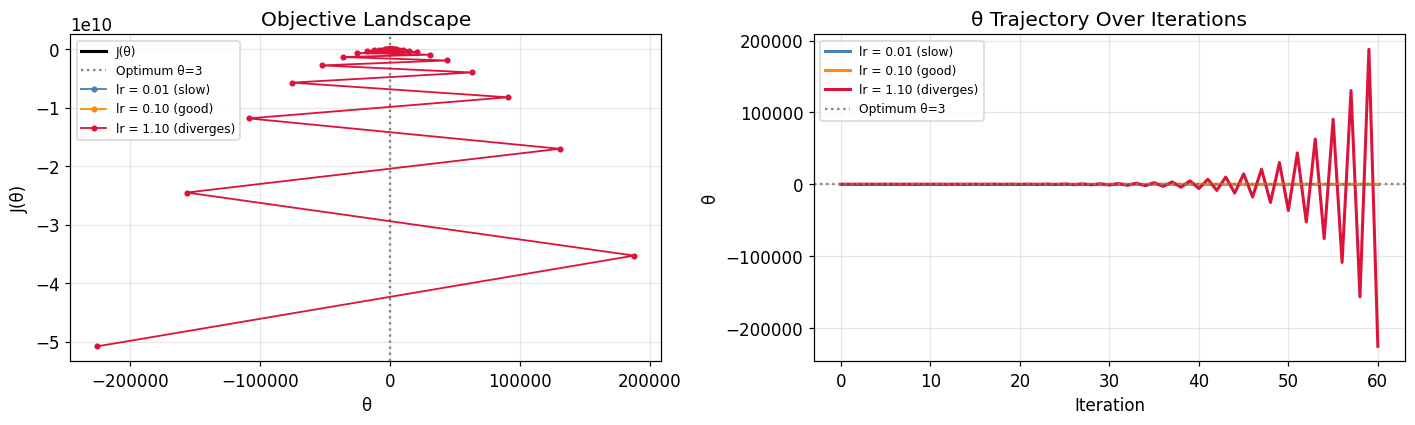

In [8]:
def J(theta: float) -> float:
    return -(theta - 3.0) ** 2


def grad_J(theta: float) -> float:
    return -2.0 * (theta - 3.0)   # ascending: use + in update


def gradient_ascent(init: float, lr: float, steps: int):
    theta = init
    history = [theta]
    for _ in range(steps):
        theta = theta + lr * grad_J(theta)
        history.append(theta)
    return history


configs = [
    {'lr': 0.01,  'color': 'steelblue',  'label': 'lr = 0.01 (slow)'},
    {'lr': 0.10,  'color': 'darkorange', 'label': 'lr = 0.10 (good)'},
    {'lr': 1.10,  'color': 'crimson',    'label': 'lr = 1.10 (diverges)'},
]

theta_range = np.linspace(-2, 8, 300)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(theta_range, [J(t) for t in theta_range], 'k-', linewidth=2, label='J(θ)')
ax1.axvline(3.0, color='gray', linestyle=':', label='Optimum θ=3')

for cfg in configs:
    hist = gradient_ascent(init=-1.0, lr=cfg['lr'], steps=60)
    ax1.plot(
        hist, [J(t) for t in hist], 'o-',
        color=cfg['color'], label=cfg['label'], markersize=3, linewidth=1.2
    )
    ax2.plot(hist, color=cfg['color'], label=cfg['label'], linewidth=2)

ax1.set_xlabel('θ'); ax1.set_ylabel('J(θ)')
ax1.set_title('Objective Landscape')
ax1.legend(fontsize=8); ax1.grid(alpha=0.3)

ax2.axhline(3.0, color='gray', linestyle=':', label='Optimum θ=3')
ax2.set_xlabel('Iteration'); ax2.set_ylabel('θ')
ax2.set_title('θ Trajectory Over Iterations')
ax2.legend(fontsize=8); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

---
## 6. Log-Probability Arithmetic and Numerical Stability

When we compute the probability of a full token sequence, we multiply together many per-token probabilities. For a 100-token sequence with average per-token probability 0.1:

$$P(\text{sequence}) = \prod_{t=1}^{100} 0.1 = 10^{-100}$$

This is far below the IEEE 754 `float32` minimum (~$1.2 \times 10^{-38}$) — it **underflows to zero**. Working in **log space** avoids this:

$$\log P(\text{sequence}) = \sum_{t=1}^{100} \log 0.1 \approx -230.26$$

That is a perfectly representable float. Every RL algorithm in this book accumulates **sums of log-probabilities**, never products of raw probabilities.

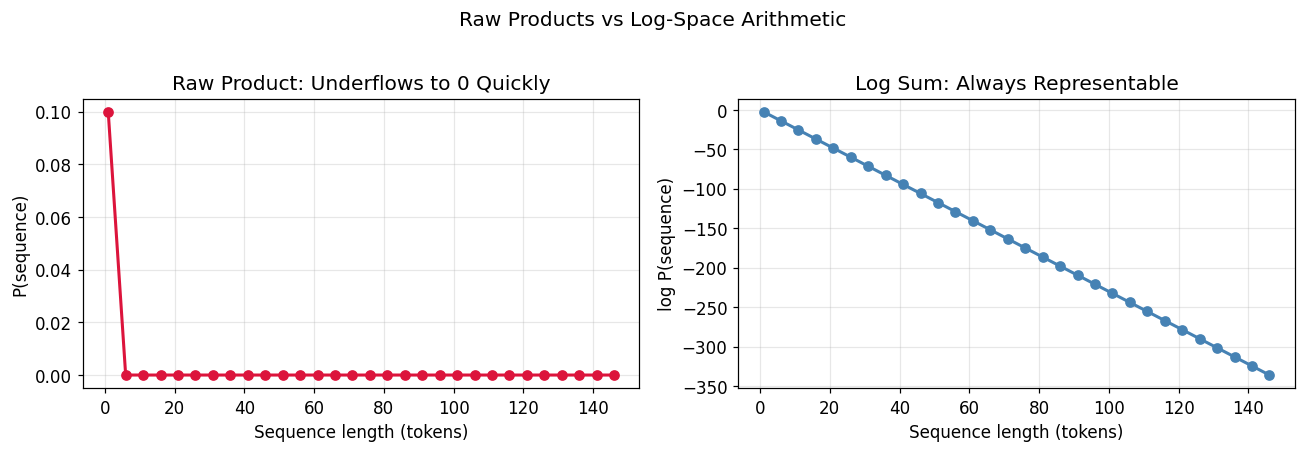

Raw product underflows to 0.0 starting at length: never (within range)
Log sum at length 40: -92.10  (well-behaved)


In [9]:
avg_token_prob = 0.1
sequence_lengths = list(range(1, 150, 5))

raw_products, log_sums = [], []
for L in sequence_lengths:
    raw_products.append(avg_token_prob ** L)
    log_sums.append(L * np.log(avg_token_prob))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(sequence_lengths, raw_products, 'o-', color='crimson', linewidth=2)
ax1.set_xlabel('Sequence length (tokens)')
ax1.set_ylabel('P(sequence)')
ax1.set_title('Raw Product: Underflows to 0 Quickly')
ax1.grid(alpha=0.3)

ax2.plot(sequence_lengths, log_sums, 'o-', color='steelblue', linewidth=2)
ax2.set_xlabel('Sequence length (tokens)')
ax2.set_ylabel('log P(sequence)')
ax2.set_title('Log Sum: Always Representable')
ax2.grid(alpha=0.3)

plt.suptitle('Raw Products vs Log-Space Arithmetic', y=1.02)
plt.tight_layout()
plt.show()

underflow_at = next(
    (L for L, p in zip(sequence_lengths, raw_products) if p == 0.0),
    'never (within range)'
)
print(f'Raw product underflows to 0.0 starting at length: {underflow_at}')
print(f'Log sum at length 40: {40 * np.log(avg_token_prob):.2f}  (well-behaved)')

In [10]:
# Log-sum-exp: the numerically stable way to compute log(sum(exp(...)))
# This is the workhorse behind log-softmax and KL divergence.

def log_sum_exp_naive(x: np.ndarray) -> float:
    return float(np.log(np.sum(np.exp(x))))


def log_sum_exp_stable(x: np.ndarray) -> float:
    m = x.max()
    return float(m + np.log(np.sum(np.exp(x - m))))


# Moderate values — both agree
x_moderate = np.array([1.0, 2.0, 3.0])
print('Moderate values:')
print(f'  Naive  : {log_sum_exp_naive(x_moderate):.6f}')
print(f'  Stable : {log_sum_exp_stable(x_moderate):.6f}')

# Large values — naive overflows to inf
x_large = np.array([800.0, 900.0, 1000.0])
naive_val = log_sum_exp_naive(x_large)
stable_val = log_sum_exp_stable(x_large)
print('\nLarge values (800, 900, 1000):')
print(f'  Naive  : {naive_val}  <- overflow (inf)')
print(f'  Stable : {stable_val:.4f}  <- correct (≈ 1000)')

Moderate values:
  Naive  : 3.407606
  Stable : 3.407606

Large values (800, 900, 1000):
  Naive  : inf  <- overflow (inf)
  Stable : 1000.0000  <- correct (≈ 1000)


/tmp/ipykernel_3083/2408244220.py:5: RuntimeWarning: overflow encountered in exp
  return float(np.log(np.sum(np.exp(x))))


---
## Summary

| Concept | Key Formula | Where Used in the Book |
|---|---|---|
| Softmax | $e^{z_i} / \sum_j e^{z_j}$ | Token sampling, policy output |
| Temperature | $\text{softmax}(z / T)$ | Decoding strategies (Ch. 2, 5) |
| KL Divergence | $\sum_i P_i \log (P_i / Q_i)$ | PPO / RLHF penalty (Ch. 6) |
| Log-derivative trick | $\nabla \pi = \pi \cdot \nabla \log \pi$ | REINFORCE (Ch. 3) |
| Monte Carlo return | $\hat{G} = \frac{1}{N}\sum_\tau G(\tau)$ | Policy gradient (Ch. 3, 4) |
| Log-sum-exp | $m + \log\sum e^{x_i - m}$ | All log-prob computations |

In **Chapter 2** we will see why LLMs trained purely on next-token prediction are misaligned with human intent, and why the tools from this chapter are needed to close that gap.

In [11]:
# Self-test — run this cell to verify key identities hold numerically
import torch
import torch.nn.functional as F

test_logits = torch.tensor([1.0, 2.0, 3.0, 4.0])

probs = F.softmax(test_logits, dim=0)
log_probs = F.log_softmax(test_logits, dim=0)

assert abs(probs.sum().item() - 1.0) < 1e-5, 'Probabilities must sum to 1'
assert torch.allclose(log_probs.exp(), probs, atol=1e-5), 'exp(log_softmax) must equal softmax'

# KL(P || P) == 0
kl_self = F.kl_div(log_probs, probs, reduction='sum')
assert abs(kl_self.item()) < 1e-5, 'KL(P || P) must equal 0'

print('All assertions passed.  Math toolkit is ready.')

All assertions passed.  Math toolkit is ready.
